In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor, MLPClassifier

# Multilayer Perceptron in Torch via Skorch

## Dataset

The dataset was generated from a deep learning model trained on the Obesity or CVD risk dataset. 
https://www.kaggle.com/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster

The data consist of the estimation of obesity levels in people from the countries of Mexico, Peru and Colombia, with ages between 14 and 61 and diverse eating habits and physical condition , data was collected using a web platform with a survey where anonymous users answered each question, then the information was processed obtaining 17 attributes and 2111 records.
The attributes related with eating habits are: Frequent consumption of high caloric food (FAVC), Frequency of consumption of vegetables (FCVC), Number of main meals (NCP), Consumption of food between meals (CAEC), Consumption of water daily (CH20), and Consumption of alcohol (CALC). The attributes related with the physical condition are: Calories consumption monitoring (SCC), Physical activity frequency (FAF), Time using technology devices (TUE), Transportation used (MTRANS)
variables obtained :
Gender, Age, Height and Weight.

NObesity values are:

- Underweight Less than 18.5
- Normal 18.5 to 24.9
- Overweight 25.0 to 29.9
- Obesity I 30.0 to 34.9
- Obesity II 35.0 to 39.9
- Obesity III Higher than 40

In [2]:
df = pd.read_csv("./Data/playground-series-s4e2/train.csv")
df

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,20753,Male,25.137087,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II
20754,20754,Male,18.000000,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
20755,20755,Male,20.101026,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II
20756,20756,Male,33.852953,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [4]:
df.nunique()

id                                20758
Gender                                2
Age                                1703
Height                             1833
Weight                             1979
family_history_with_overweight        2
FAVC                                  2
FCVC                                934
NCP                                 689
CAEC                                  4
SMOKE                                 2
CH2O                               1506
SCC                                   2
FAF                                1360
TUE                                1297
CALC                                  3
MTRANS                                5
NObeyesdad                            7
dtype: int64

In [5]:
# Split the data into features and target variable

target = "NObeyesdad"
y = df[target]
X = df.drop(columns=[target, "id"])

In [6]:
# Convert categorical variables to numeric using one-hot encoding

X[X.select_dtypes('object').columns] = X.select_dtypes('object').apply(pd.Categorical)
X = pd.get_dummies(X, drop_first=True).astype(np.float32).values

In [7]:
# Convert labels to numeric using LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
np.unique(y), le.classes_

(array([0, 1, 2, 3, 4, 5, 6]),
 array(['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
        'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
        'Overweight_Level_II'], dtype=object))

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16606, 22), (4152, 22), (16606,), (4152,))

### Dummy Classifier

In [9]:
from sklearn.dummy import DummyClassifier

model = DummyClassifier(strategy="most_frequent")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.06282803118308164

## MLP with Sklearn

In [10]:
model =  MLPClassifier(
    hidden_layer_sizes=(32,),  
    solver="adam",  
    alpha=0.001, 
    max_iter=500,  
    random_state=42,  
    batch_size=2048,  
    shuffle=True,
    
    # parameters for early stopping
    early_stopping=True,  # whether to use early stopping to terminate training when validation score is not improving
    n_iter_no_change=50,  # maximum number of epochs to not meet tol improvement
    validation_fraction=0.1,  # proportion of training data to set aside as validation set for early stopping
)

In [11]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


0.8338739595965879

## MLP with Skorch

Skorch is a lightweight library that wraps PyTorch with a scikit-learn style interface. It lets you train neural networks, such as an MLP, using familiar methods like `fit`, `predict`, and `score`, while still keeping the flexibility of PyTorch for defining custom models and training logic.

For this notebook, Skorch is useful because it makes PyTorch models easier to integrate into standard machine learning workflows, including preprocessing pipelines, cross-validation, and hyperparameter tuning.


In [12]:
import torch
from torch import nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier
from skorch.callbacks import EpochScoring

In [ ]:
# Define the MLP architecture. cpu will always work, but if you have a GPU you can use it to speed up training.
DEVICE = 'mps'
DEVICE = 'cuda'
DEVICE = 'cpu'

#### Vanilla

In [14]:
class VanillaMLP(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.Linear(32, out_features),
            nn.Softmax(dim=-1),  
        )

    def forward(self, X, **kwargs):
        return self.model(X)

##### First attempt: no scaling, mostly default parameters

In [15]:
net = NeuralNetClassifier(
    VanillaMLP,
    module__in_features=X_train.shape[1],
    module__out_features=len(le.classes_),

    max_epochs=200,
    lr=0.01,
    batch_size=2048,  # default is 128, but we can increase it for better performance on GPU

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
        ),
    ],
    device=DEVICE,
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.VanillaMLP'>,
  module__in_features=22,
  module__out_features=7,
)

In [16]:
net.fit(X_train, y_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss     dur
-------  -----------  ------------  -----------  ------------  ------
      1       0.1431        4.2396       0.1942        1.9763  2.0555
      2       0.1973        1.9649       0.1671        1.9494  0.0686
      3       0.2054        1.9431       0.1942        1.9290  0.0739
      4       0.2138        1.9208       0.2008        1.9087  0.0683
      5       0.2298        1.9030       0.2026        1.8917  0.0672
      6       0.2053        1.8856       0.2050        1.8748  0.0655
      7       0.2090        1.8680       0.2083        1.8568  0.0655
      8       0.2145        1.8494       0.2092        1.8382  0.0678
      9       0.2190        1.8303       0.2137        1.8197  0.0664
     10       0.2209        1.8122       0.2146        1.8025  0.1078
     11       0.2238        1.7947       0.2143        1.7855  0.0720
     12       0.2255        1.7773       0.2164        1.7695  0.0719
     13       0.2291

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=VanillaMLP(
    (model): Sequential(
      (0): Linear(in_features=22, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=7, bias=True)
      (3): Softmax(dim=-1)
    )
  ),
)

In [17]:
y_pred = net.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.3754543665724024

In [18]:
net.criterion, net.optimizer

(torch.nn.modules.loss.NLLLoss, torch.optim.sgd.SGD)

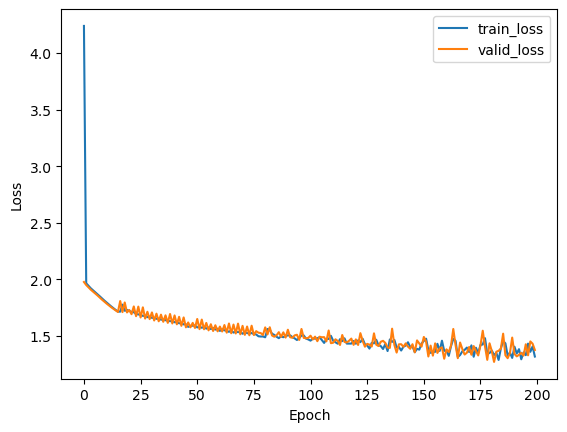

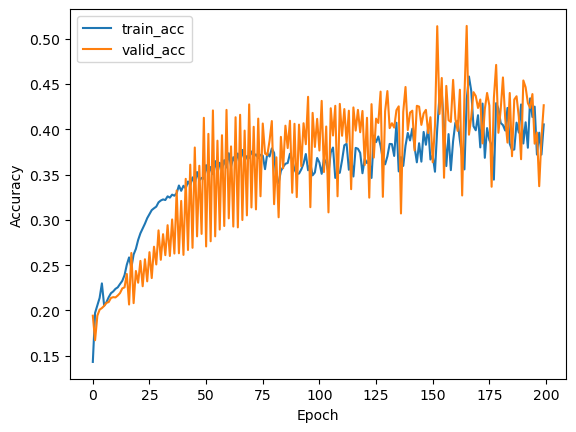

In [19]:
history = net.history
plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

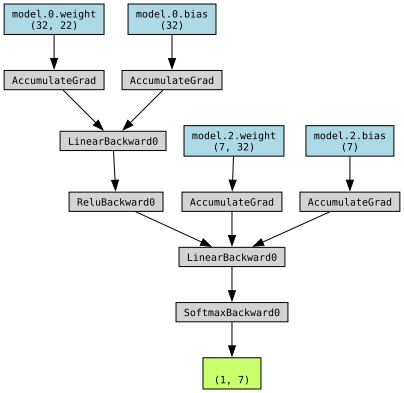

In [20]:
from torchviz import make_dot


make_dot(
    net.module_(torch.as_tensor(X[:1], dtype=torch.float32).to(net.device)),
    params=dict(net.module_.named_parameters()),
    show_attrs=False,
    # show_saved=True,
)

#### Adam

In [21]:
net = NeuralNetClassifier(
    VanillaMLP,
    module__in_features=X_train.shape[1],
    module__out_features=len(le.classes_),
    max_epochs=500,
    
    
    device=DEVICE,
    optimizer=torch.optim.Adam,
    lr=1e-3,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
            lower_is_better=False
        ),
    ],

    batch_size=2048,
    iterator_train__shuffle=True,
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.VanillaMLP'>,
  module__in_features=22,
  module__out_features=7,
)

In [22]:
# Training the network
net.fit(X_train, y_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss     dur
-------  -----------  ------------  -----------  ------------  ------
      1       0.1055        2.8612       0.1620        2.2308  0.1646
      2       0.1413        2.0745       0.2203        1.9541  0.0784
      3       0.2041        1.9657       0.2008        1.9668  0.0792
      4       0.2097        1.9434       0.2219        1.9088  0.0757
      5       0.2224        1.8955       0.2375        1.8621  0.0764
      6       0.2520        1.8455       0.2288        1.8194  0.0739
      7       0.2314        1.8114       0.2673        1.7938  0.0741
      8       0.2886        1.7870       0.2655        1.7698  0.0736
      9       0.3005        1.7623       0.2971        1.7436  0.0748
     10       0.2797        1.7372       0.2878        1.7211  0.0738
     11       0.3106        1.7143       0.3359        1.6989  0.0745
     12       0.3443        1.6926       0.3471        1.6771  0.0742
     13       0.3371

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=VanillaMLP(
    (model): Sequential(
      (0): Linear(in_features=22, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=7, bias=True)
      (3): Softmax(dim=-1)
    )
  ),
)

In [23]:
y_pred = net.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.8323364703729181

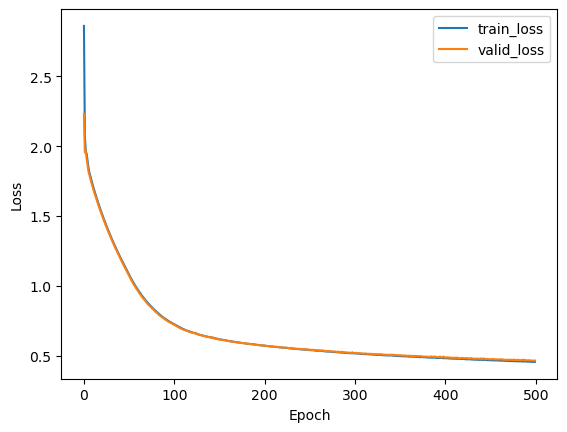

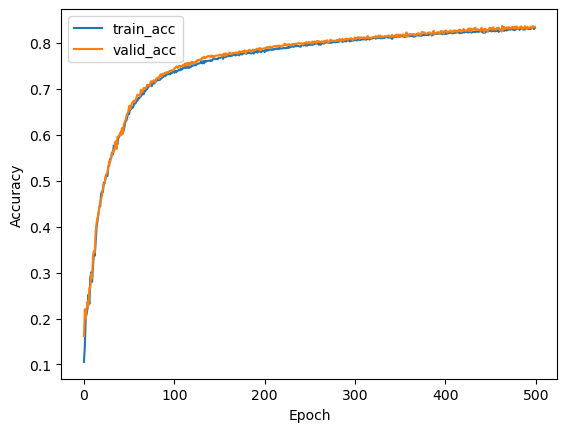

In [24]:
history = net.history

plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

#### Pipeline with normalization

In [25]:
net = NeuralNetClassifier(
    VanillaMLP,
    module__in_features=X_train.shape[1],
    module__out_features=len(le.classes_),
    max_epochs=500,
    
    
    device=DEVICE,
    optimizer=torch.optim.Adam,
    lr=1e-2,

    callbacks=[
        EpochScoring(
            scoring='accuracy',
            name='train_acc',
            on_train=True,
            lower_is_better=False,
        ),
    ],

    batch_size=2048,
    iterator_train__shuffle=True,
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.VanillaMLP'>,
  module__in_features=22,
  module__out_features=7,
)

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipe = make_pipeline(StandardScaler(), net)
pipe

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('neuralnetclassifier',
                 NeuralNetClassifier(_params_to_validate={'iterator_train__shuffle', 'module__out_features', 'module__in_features'}, batch_size=2048, callbacks=[<skorch.callbacks.scoring.EpochScoring object at 0x31b2738c0>], compile=False, dataset=<class 'skorch.dataset.Dataset'>, device='mps', iterator...ataLoader'>, iterator_train__shuffle=True, iterator_valid=<class 'torch.utils.data.dataloader.DataLoader'>, lr=0.01, max_epochs=500, module=<class '__main__.VanillaMLP'>, module__in_features=22, module__out_features=7, optimizer=<class 'torch.optim.adam.Adam'>, predict_nonlinearity='auto', torch_load_kwargs=None, use_caching='auto', verbose=1, warm_start=False))])

In [27]:
# Training the network
pipe.fit(X_train, y_train)

  epoch    train_acc    train_loss    valid_acc    valid_loss     dur
-------  -----------  ------------  -----------  ------------  ------
      1       0.3780        1.7503       0.5406        1.4481  0.0785
      2       0.5583        1.2945       0.5939        1.0888  0.0761
      3       0.6043        1.0283       0.6276        0.9224  0.0770
      4       0.6506        0.8943       0.6749        0.8287  0.0760
      5       0.6817        0.8096       0.7014        0.7643  0.0801
      6       0.7104        0.7471       0.7279        0.7110  0.0961
      7       0.7334        0.6930       0.7486        0.6616  0.0852
      8       0.7594        0.6437       0.7673        0.6199  0.0786
      9       0.7736        0.6025       0.7857        0.5844  0.0784
     10       0.7901        0.5679       0.7977        0.5549  0.0763
     11       0.8007        0.5389       0.8079        0.5319  0.0736
     12       0.8143        0.5128       0.8164        0.5104  0.0741
     13       0.8196

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('neuralnetclassifier',
                 NeuralNetClassifier(_params_to_validate={'iterator_train__shuffle', 'module__out_features', 'module__in_features'}, batch_size=2048, callbacks=[<skorch.callbacks.scoring.EpochScoring object at 0x31b2738c0>], compile=False, dataset=<class 'skorch.dataset.Dataset'>, device='mps', iterator...ataLoader'>, iterator_train__shuffle=True, iterator_valid=<class 'torch.utils.data.dataloader.DataLoader'>, lr=0.01, max_epochs=500, module=<class '__main__.VanillaMLP'>, module__in_features=22, module__out_features=7, optimizer=<class 'torch.optim.adam.Adam'>, predict_nonlinearity='auto', torch_load_kwargs=None, use_caching='auto', verbose=1, warm_start=False))])

In [28]:
y_pred = pipe.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.8655852188076297

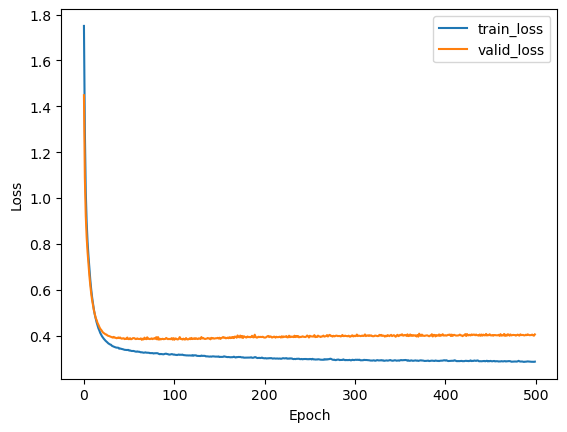

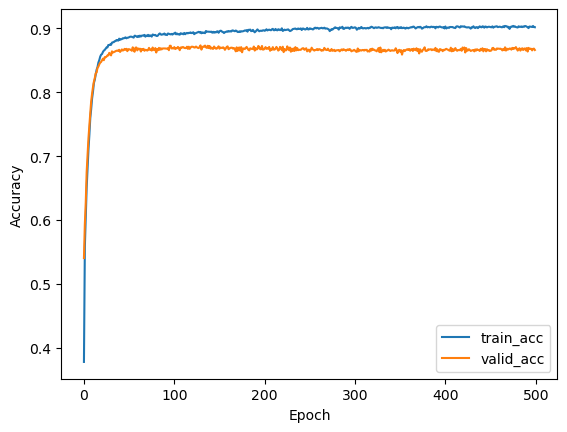

In [29]:
history = pipe[1].history

plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_acc'], label='train_acc')
plt.plot(history[:, 'valid_acc'], label='valid_acc')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

### Improving the model

In [30]:
class BetterMLP(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.BatchNorm1d(32),  # batch normalization layer
            nn.ReLU(),
            nn.Dropout(p=0.2),  # dropout layer with 20% dropout rate
            nn.Linear(32, out_features),
            nn.Softmax(dim=-1),
        )

    def forward(self, X, **kwargs):
        return self.model(X)

#### The better model, monitoring F1 besides Acc

In [31]:
net = NeuralNetClassifier(
    BetterMLP,
    module__in_features=X_train.shape[1],
    module__out_features=len(le.classes_),
    max_epochs=500,
    
    lr = 1e-3,
    device=DEVICE,
    optimizer=torch.optim.Adam,

    callbacks=[
        EpochScoring(
            scoring='f1_weighted',
            name='train_f1',
            on_train=True,
            lower_is_better=False,
        ),
        EpochScoring(
            scoring='f1_weighted',
            name='valid_f1',
            on_train=False,
            lower_is_better=False,
        ),
    ],

    batch_size=2048,
    iterator_train__shuffle=True,
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.BetterMLP'>,
  module__in_features=22,
  module__out_features=7,
)

In [32]:
# Training the network
net.fit(X_train, y_train)

  epoch    train_f1    train_loss    valid_acc    valid_f1    valid_loss     dur
-------  ----------  ------------  -----------  ----------  ------------  ------
      1      0.0712        1.9186       0.1469      0.0382        2.5864  1.0286
      2      0.0943        1.8163       0.1328      0.0501        1.9488  0.0847
      3      0.1528        1.7282       0.2098      0.1403        1.7196  0.0836
      4      0.2173        1.6527       0.3281      0.2249        1.6047  0.0888
      5      0.2647        1.5878       0.3326      0.2299        1.5355  0.0932
      6      0.3042        1.5298       0.3064      0.2185        1.4855  0.0900
      7      0.3294        1.4790       0.3200      0.2436        1.4443  0.0861
      8      0.3486        1.4336       0.3323      0.2344        1.4102  0.0828
      9      0.3643        1.3945       0.3320      0.2237        1.3842  0.0830
     10      0.3936        1.3611       0.3347      0.2252        1.3619  0.1050
     11      0.4126        1

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=BetterMLP(
    (model): Sequential(
      (0): Linear(in_features=22, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=32, out_features=7, bias=True)
      (5): Softmax(dim=-1)
    )
  ),
)

In [33]:
y_pred = net.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.8731897654334311

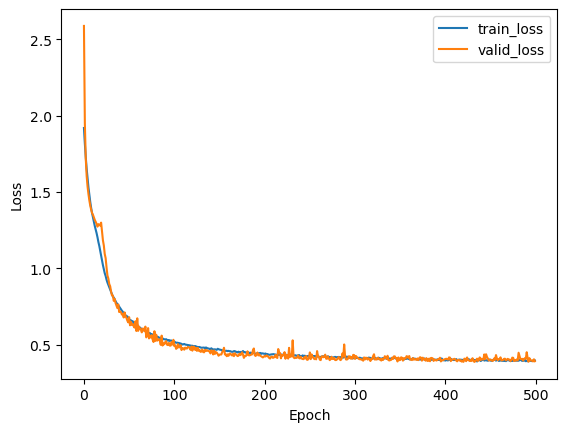

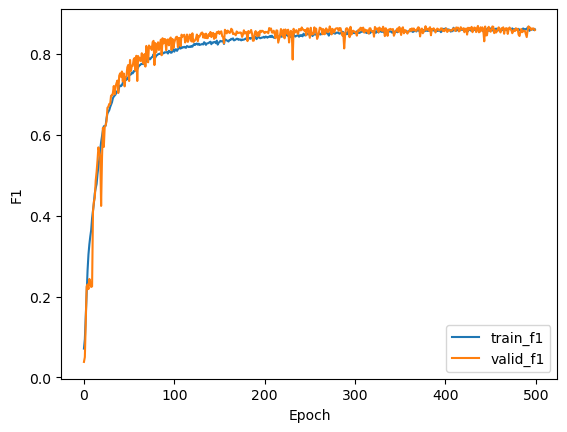

In [34]:
history = net.history

plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(history[:, 'train_f1'], label='train_f1')
plt.plot(history[:, 'valid_f1'], label='valid_f1')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.show()

#### Better Training

In [35]:
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint
from torch.optim.lr_scheduler import ReduceLROnPlateau


In [36]:
class BetterMLP(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.BatchNorm1d(32),  # batch normalization layer
            nn.ReLU(),
            nn.Dropout(p=0.2),  # dropout layer with 20% dropout rate
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, out_features),
            nn.Softmax(dim=-1),
        )

    def forward(self, X, **kwargs):
        return self.model(X)

In [37]:
from skorch.dataset import ValidSplit

net = NeuralNetClassifier(
    BetterMLP,
    module__in_features=X_train.shape[1],
    module__out_features=len(le.classes_),
    max_epochs=500,
    
    lr = 1e-3,
    device=DEVICE,
    optimizer=torch.optim.AdamW,  # using AdamW instead of Adam for better regularization

    callbacks=[
        EpochScoring(
            scoring='f1_weighted',
            name='train_f1',
            on_train=True,
            lower_is_better=False,
        ),
        EpochScoring(
            scoring='f1_weighted',
            name='valid_f1',
            on_train=False,
            lower_is_better=False,
        ),
        EarlyStopping(
            monitor="valid_f1",
            patience=50,
            lower_is_better=False,
        ),
        LRScheduler(
            policy=ReduceLROnPlateau,
            monitor="valid_f1",     
            mode="max",              
            factor=0.5,              
            patience=25,       
            threshold=1e-4,
            min_lr=1e-6,
            verbose=True,
        ),
        Checkpoint(
            monitor="valid_acc_best", 
            load_best=True,
            f_history=None,
            f_optimizer=None,
        )
    ],
    train_split=ValidSplit(cv=5, stratified=True),

    batch_size=2048,
    iterator_train__shuffle=True,
)
net

<class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.BetterMLP'>,
  module__in_features=22,
  module__out_features=7,
)

In [38]:
# Training the network
net.fit(X_train, y_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  epoch    train_f1    train_loss    valid_acc    valid_f1    valid_loss    cp      lr     dur
-------  ----------  ------------  -----------  ----------  ------------  ----  ------  ------
      1      0.0830        1.9260       0.2914      0.1600        1.9539     +  0.0010  0.4120
      2      0.1850        1.8699       0.2718      0.1739        1.8814        0.0010  0.1013
      3      0.2015        1.8139       0.3104      0.1848        1.8047     +  0.0010  0.1000
      4      0.1937        1.7535       0.3152      0.1703        1.7270     +  0.0010  0.0916
      5      0.1846        1.6877       0.3170      0.1677        1.6488     +  0.0010  0.0918
      6      0.1801        1.6216       0.3209      0.1745        1.5796     +  0.0010  0.0918
      7      0.1797        1.5583       0.3200      0.1732        1.5111        0.0010  0.0880
      8      0.1845        1.5001       0.3104      0.1737        1.4591        0.0010  0.0891
      9      0.1917        1.4470       0.2914    

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=BetterMLP(
    (model): Sequential(
      (0): Linear(in_features=22, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=32, out_features=16, bias=True)
      (5): ReLU()
      (6): Linear(in_features=16, out_features=7, bias=True)
      (7): Softmax(dim=-1)
    )
  ),
)

In [39]:
y_pred = net.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.8739429187585216

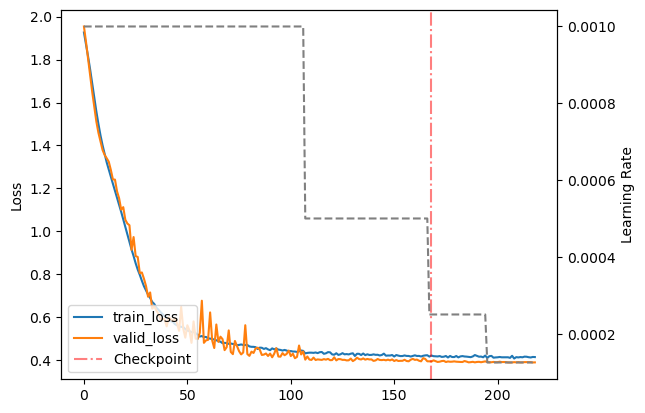

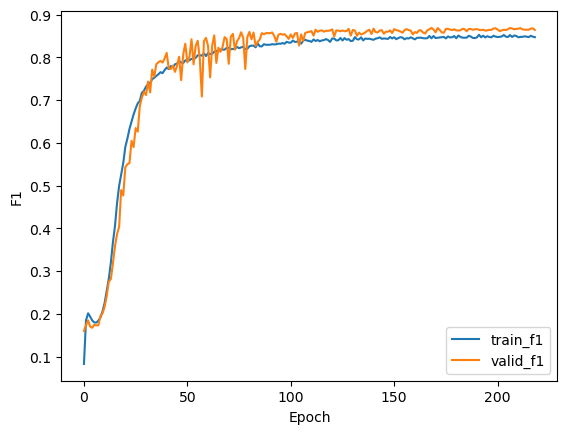

In [40]:
history = net.history

plt.plot(history[:, 'train_loss'], label='train_loss')
plt.plot(history[:, 'valid_loss'], label='valid_loss')
ax1 = plt.gca()  # get current axes
ax2 = plt.gca().twinx()  # create a second y-axis
plt.plot(history[:, "event_lr"], label='learning_rate', color='gray', linestyle='--')
ax2.set_ylabel('Learning Rate')

ax1.set_ylabel('Loss')

for i, checkpoint in enumerate(history[:, "event_cp"][::-1]):
    if checkpoint:
        ax1.axvline(x=len(history[:, "event_cp"])-i-1, color='red', 
                    linestyle='-.', label='Checkpoint', alpha=0.5)
        break

ax1.legend(loc='lower left')

plt.xlabel('Epoch')
plt.show()

plt.plot(history[:, 'train_f1'], label='train_f1')
plt.plot(history[:, 'valid_f1'], label='valid_f1')

plt.xlabel('Epoch')
plt.ylabel('F1')

plt.legend()

plt.show()

## Regression

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
import torch
from torch import nn
import torch.nn.functional as F
from skorch import NeuralNetClassifier
from skorch.callbacks import EpochScoring
from sklearn.metrics import mean_absolute_error
from skorch import NeuralNetRegressor

In [42]:
target = "Age"
y = df[target].astype(np.float32).values
X = df.drop(columns=[target, "id"])

In [43]:
# Convert categorical variables to numeric using one-hot encoding

X[X.select_dtypes('object').columns] = X.select_dtypes('object').apply(pd.Categorical)
X = pd.get_dummies(X, drop_first=True).astype(np.float32).values

In [44]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
from sklearn.dummy import DummyRegressor

model = DummyRegressor(strategy="mean")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mean_absolute_error(y_test, y_pred)

4.175730228424072

In [46]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(32,),  
    solver="adam",  
    alpha=0.001, 
    max_iter=500,  
    random_state=42,  
    batch_size=2048,  
    shuffle=True,
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mean_absolute_error(y_test, y_pred)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


2.272099018096924

In [47]:
class BetterMLP(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.BatchNorm1d(32),  # batch normalization layer
            nn.ReLU(),
            nn.Linear(32, out_features),
            # no activation at the end since this is regression
        )

    def forward(self, X, **kwargs):
        return self.model(X)

In [48]:
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, Checkpoint
from torch.optim.lr_scheduler import ReduceLROnPlateau


net = NeuralNetRegressor(
    BetterMLP,
    module__in_features=X_train.shape[1],
    module__out_features=1,
    max_epochs=500,
    
    lr = 1e-3,
    device=DEVICE,
    optimizer=torch.optim.AdamW,  # using AdamW instead of Adam for better regularization
    criterion=nn.MSELoss,  # using MSE loss for regression

    callbacks=[
        EpochScoring(
            mean_absolute_error,
            name="valid_mae",
            lower_is_better=True,
            on_train=False,
        ),
        EpochScoring(
            mean_absolute_error,
            name="train_mae",
            lower_is_better=True,
            on_train=True,
        ),
        LRScheduler(
            policy=ReduceLROnPlateau,
            monitor="valid_mae",
            mode="min",
            factor=0.5,
            patience=25,
            threshold=1e-4,
            min_lr=1e-6,
            verbose=True,
        ),
        EarlyStopping(
            monitor="valid_mae",
            lower_is_better=True,
            patience=40,
            load_best=True,
        ),
        Checkpoint(
            monitor="valid_mae_best",
            load_best=True,
            f_history=None,
            f_optimizer=None,
        ),
    ],

    batch_size=2048,
    iterator_train__shuffle=True,
)
net

<class 'skorch.regressor.NeuralNetRegressor'>[uninitialized](
  module=<class '__main__.BetterMLP'>,
  module__in_features=27,
  module__out_features=1,
)

In [49]:
# Training the network
net.fit(X_train, y_train[:, None])

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


  epoch    train_loss    train_mae    valid_loss    valid_mae    cp      lr     dur
-------  ------------  -----------  ------------  -----------  ----  ------  ------
      1      615.6085      24.1479      620.8583      24.2237     +  0.0010  0.7635
      2      609.6344      24.0249      594.3533      23.6981     +  0.0010  0.0959
      3      603.7377      23.9016      584.2501      23.4937     +  0.0010  0.0958
      4      597.9963      23.7810      582.1346      23.4469     +  0.0010  0.0967
      5      592.3411      23.6611      583.7179      23.4732        0.0010  0.1025
      6      586.7383      23.5401      585.3101      23.4981        0.0010  0.1052
      7      581.1118      23.4179      581.9609      23.4199     +  0.0010  0.1372
      8      575.3965      23.2951      577.8797      23.3286     +  0.0010  0.0998
      9      569.5366      23.1720      566.8957      23.0928     +  0.0010  0.1016
     10      563.5585      23.0449      554.6788      22.8320     +  0.0010 

<class 'skorch.regressor.NeuralNetRegressor'>[initialized](
  module_=BetterMLP(
    (model): Sequential(
      (0): Linear(in_features=27, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=32, out_features=1, bias=True)
    )
  ),
)

In [50]:
y_pred = net.predict(X_test)
mean_absolute_error(y_test, y_pred)

2.0315136909484863

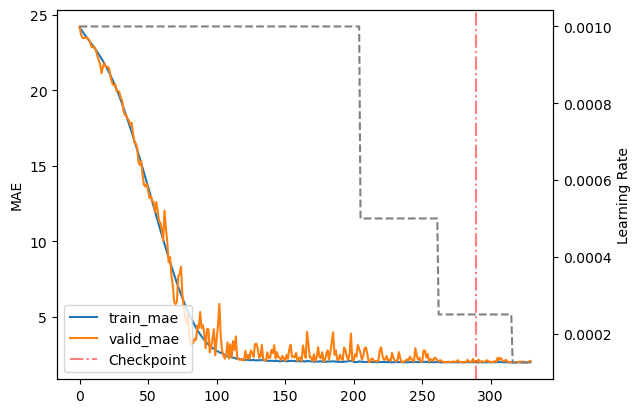

In [51]:
history = net.history

plt.plot(history[:, 'train_mae'], label='train_mae')
plt.plot(history[:, 'valid_mae'], label='valid_mae')
ax1 = plt.gca()  # get current axes
ax2 = plt.gca().twinx()  # create a second y-axis
plt.plot(history[:, "event_lr"], label='learning_rate', color='gray', linestyle='--')
ax2.set_ylabel('Learning Rate')

ax1.set_ylabel('MAE')

for i, checkpoint in enumerate(history[:, "event_cp"][::-1]):
    if checkpoint:
        ax1.axvline(x=len(history[:, "event_cp"])-i-1, color='red', 
                    linestyle='-.', label='Checkpoint', alpha=0.5)
        break

ax1.legend(loc='lower left')

plt.xlabel('Epoch')
plt.show()


# Exercise
Build an MLP to predict whether a patient has an in-hospital complication, based on features like BMI, age, etc.
- use a dummy baseline that always predicts 1
- use an sklearn MLP
- use a torch MLP

optimize for F1-score w.r.t. the positive class: 

```python
f1_score(y_pred, y_test)  # no "weighted"
```

Plot the loss curves for the torch model

In [52]:
df = pd.read_csv("./Data/surgical_complications.csv")
df

,bmi,Age,asa_status,baseline_cancer,baseline_charlson,baseline_cvd,baseline_dementia,baseline_diabetes,baseline_digestive,baseline_osteoart,...,complication_rsi,dow,gender,hour,month,moonphase,mort30,mortality_rsi,race,complication
0,19.31,59.2,1,1,0,0,0,0,0,0,...,-0.57,3,0,7.63,6,1,0,-0.43,1,0
1,18.73,59.1,0,0,0,0,0,0,0,0,...,0.21,0,0,12.93,0,1,0,-0.41,1,0
2,21.85,59.0,0,0,0,0,0,0,0,0,...,0.00,2,0,7.68,5,3,0,0.08,1,0
3,18.49,59.0,1,0,1,0,0,1,1,0,...,-0.65,2,1,7.58,4,3,0,-0.32,1,0
4,19.70,59.0,1,0,0,0,0,0,0,0,...,0.00,0,0,7.88,11,0,0,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14630,18.79,14.1,1,0,1,0,0,0,0,0,...,-0.54,1,0,7.78,0,1,0,-0.16,1,1
14631,19.65,12.6,0,0,0,0,0,0,0,0,...,-1.42,4,0,8.40,6,1,0,-0.77,1,1
14632,14.84,12.6,1,0,0,0,0,0,0,0,...,0.65,0,0,13.25,3,3,0,0.99,1,1
14633,17.75,8.9,0,0,1,0,0,0,1,0,...,-0.50,0,1,8.30,5,0,0,0.17,1,1


In [53]:
target = "complication"
X = df.drop(columns=[target]).values.astype(np.float32)
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)